# Leer un archivo WAV con `librosa`

En este cuadernillo reforzaremos el flujo más básico para trabajar con una señal de audio:

```text
archivo WAV → señal x → frecuencia de muestreo sr → duración → gráfico → reproducción
```

Antes de procesar muchos archivos, necesitamos dominar muy bien cómo leer **un solo archivo WAV**.

## 1. Importar librerías

Usaremos `librosa` para leer audio, `numpy` para trabajar con arreglos, `matplotlib` para graficar y `Audio` para escuchar señales dentro del cuadernillo.

In [22]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import librosa
from IPython.display import Audio

## 2. Definir la carpeta donde estarán los audios

Los archivos `.wav` deben estar dentro de:

```text
data/audio/
```

Como este cuadernillo está dentro de `notebooks/`, usamos `../data/audio`.

In [23]:
audio_dir = Path("../data/audio_tracks")

print("Carpeta de audios:")
print(audio_dir)

Carpeta de audios:
..\data\audio_tracks


## 3. Buscar archivos WAV disponibles

Primero revisamos qué archivos `.wav` hay en la carpeta.

In [25]:
wav_files = sorted(audio_dir.glob("*.wav"))

print("Número de archivos WAV encontrados:", len(wav_files))

for file in wav_files:
    print("-", file.name)

Número de archivos WAV encontrados: 2
- anecoica_flauta.wav
- anecoica_voz_01.wav


## 4. Seleccionar un archivo WAV

Para comenzar seleccionaremos el primer archivo encontrado.

Si no aparece ningún archivo, debes copiar al menos un `.wav` dentro de `data/audio/`.

In [26]:
file_path = wav_files[0] if wav_files else None

print("Archivo seleccionado:")
print(file_path)

Archivo seleccionado:
..\data\audio_tracks\anecoica_flauta.wav


## 5. Leer el archivo con `librosa.load`

La función principal será:

```python
x, sr = librosa.load(file_path, sr=None, mono=True)
```

Esto entrega:

- `x`: señal de audio como arreglo NumPy.
- `sr`: frecuencia de muestreo en Hz.

Usamos `sr=None` para mantener la frecuencia de muestreo original del archivo.  
Usamos `mono=True` para trabajar con una sola señal.

In [27]:
x, sr = librosa.load(file_path, sr=None, mono=True)

print("Archivo:", file_path.name)
print("Tipo de x:", type(x))
print("Forma de x:", x.shape)
print("Tipo numérico de x:", x.dtype)
print("Frecuencia de muestreo sr:", sr, "Hz")

Archivo: anecoica_flauta.wav
Tipo de x: <class 'numpy.ndarray'>
Forma de x: (720000,)
Tipo numérico de x: float32
Frecuencia de muestreo sr: 48000 Hz


## 6. ¿Qué contiene la variable `x`?

La variable `x` contiene las muestras de la señal de audio.  
Cada número representa la amplitud de la señal en un instante discreto.

In [28]:
print("Primeras 20 muestras de la señal:")
print(x[:20])

Primeras 20 muestras de la señal:
[0.00000000e+00 5.52253576e-10 2.38526554e-09 5.32422195e-09
 9.17980181e-09 1.49751305e-08 2.15218670e-08 2.76481220e-08
 3.69041899e-08 4.87467098e-08 6.01989782e-08 7.43909752e-08
 8.54631494e-08 1.03750921e-07 1.14539894e-07 1.23973180e-07
 1.46610887e-07 1.72723730e-07 1.90088343e-07 2.05400767e-07]


## 7. Número de muestras

El número total de muestras se obtiene con:

```python
len(x)
```

In [29]:
num_samples = len(x)

print("Número total de muestras:", num_samples)

Número total de muestras: 720000


## 8. Frecuencia de muestreo

La frecuencia de muestreo indica cuántas muestras hay por segundo.

Por ejemplo, si `sr = 44100 Hz`, entonces hay 44100 muestras por cada segundo de audio.

In [30]:
print("Frecuencia de muestreo:", sr, "muestras por segundo")

Frecuencia de muestreo: 48000 muestras por segundo


## 9. Calcular la duración del audio

La duración se calcula como:

$
\text{duración} = \frac{\text{número de muestras}}{\text{frecuencia de muestreo}}
$

En Python:

```python
duration = len(x) / sr
```

In [31]:
duration = num_samples / sr

print("Duración en segundos:", duration)
print("Duración en minutos:", duration / 60)
print(f"Duración aproximada: {duration:.2f} s")

Duración en segundos: 15.0
Duración en minutos: 0.25
Duración aproximada: 15.00 s


## 10. Crear el eje de tiempo

Para graficar la señal en el tiempo necesitamos construir un vector de tiempo.

Si la señal tiene `N` muestras, los índices son:

```text
0, 1, 2, 3, ..., N-1
```

Para convertir estos índices a segundos, dividimos por `sr`.

In [32]:
t = np.arange(num_samples) / sr

print("Primeros 10 valores del eje de tiempo:")
print(t[:10])

print("Último valor del eje de tiempo:")
print(t[-1])

Primeros 10 valores del eje de tiempo:
[0.00000000e+00 2.08333333e-05 4.16666667e-05 6.25000000e-05
 8.33333333e-05 1.04166667e-04 1.25000000e-04 1.45833333e-04
 1.66666667e-04 1.87500000e-04]
Último valor del eje de tiempo:
14.999979166666666


## 11. Graficar la forma de onda

Ahora visualizamos la señal en el dominio del tiempo.

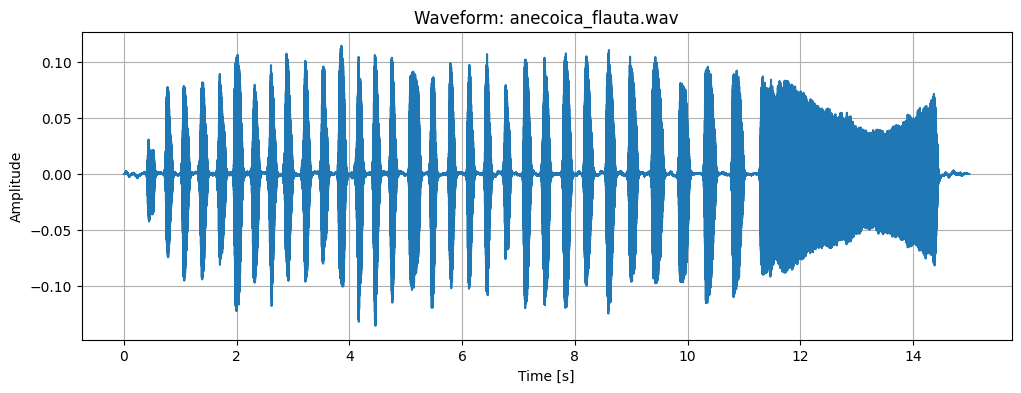

Archivo 'chunk.wav' guardado con éxito.


In [35]:
plt.figure(figsize=(12, 4))
plt.plot(t, x)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title(f"Waveform: {file_path.name}")
plt.grid(True)
plt.show()

import soundfile as sf

Audio(x, rate=sr)
sf.write("chunk.wav", x, sr)
print("Archivo 'chunk.wav' guardado con éxito.")

In [ ]:
audio_dir = Path("../data/audio_tracks")
sf.write(audio_dir / "chunk.wav", x, sr)
audio_dir = Path("../data/audio_tracks")
sf.write(audio_dir / "chunk.wav", x, sr)

x_c, sr_c = librosa.load(audio_dir / "chunk.wav", sr=None, mono=True)
duration_c = len(x_c) / sr_c

t_c = np.arange(len(x_c)) / sr_c

plt.figure(figsize=(12, 4))
plt.plot(t_c, x_c)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Waveform: chunk.wav")
plt.grid(True)
plt.show()
t_c = np.arange(len(x_c)) / sr_c

plt.figure(figsize=(12, 4))
plt.plot(t_c, x_c)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Waveform: chunk.wav")
plt.grid(True)
plt.show()

NameError: name 'x_c' is not defined

In [20]:
x_fft = x_c - np.mean(x_c)

window = np.hanning(len(x_fft))
x_windowed = x_fft * window
X = np.fft.rfft(x_windowed)
frequencies = np.fft.rfftfreq(len(x_windowed), d=1/sr_c)

X_magnitude = np.abs(X)
plt.figure(figsize=(12, 4))
plt.plot(frequencies, X_magnitude)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("Magnitude Spectrum of chunk.wav")
plt.xlim(0, sr_c / 2)
plt.grid(True)
plt.show()
X_magnitude_db = 20 * np.log10(X_magnitude + 1e-6)

plt.figure(figsize=(12, 4))
plt.plot(frequencies, X_magnitude_db)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.title("Magnitude Spectrum (dB) of chunk.wav")
plt.xlim(0, sr_c / 2)
plt.grid(True)
plt.show()

mask = (frequencies >= fmin) & (frequencies <= fmax)

frequencies_range = frequencies[mask]
X_magnitude_db_range = X_magnitude_db[mask]

peak_idx = np.argmax(X_magnitude_db_range)
peak_freq = frequencies_range[peak_idx]
print(f"Frecuencia con mayor magnitud en el rango {fmin}-{fmax} Hz: {peak_freq:.2f} Hz")

NameError: name 'x_c' is not defined

## 12. Escuchar el audio

Podemos escuchar el archivo directamente dentro del cuadernillo.

In [ ]:
Audio(x, rate=sr)

## 13. Graficar solo los primeros segundos

A veces una señal completa es muy larga. Para observar mejor la forma de onda, podemos graficar solo un tramo corto.

In [ ]:
seconds_to_plot = 2

samples_to_plot = int(seconds_to_plot * sr)

t_short = t[:samples_to_plot]
x_short = x[:samples_to_plot]

plt.figure(figsize=(12, 4))
plt.plot(t_short, x_short)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title(f"First {seconds_to_plot} seconds: {file_path.name}")
plt.grid(True)
plt.show()

## 14. Resumen automático del archivo

Esta celda reúne la información principal de la señal.

In [ ]:
print("Resumen del archivo")
print("-------------------")
print("Nombre:", file_path.name)
print("Frecuencia de muestreo:", sr, "Hz")
print("Número de muestras:", num_samples)
print("Duración:", f"{duration:.2f}", "s")
print("Duración:", f"{duration/60:.2f}", "min")
print("Valor mínimo:", np.min(x))
print("Valor máximo:", np.max(x))
print("Valor medio:", np.mean(x))

## 15. Función para inspeccionar un archivo WAV

Ahora transformamos los pasos anteriores en una función. Esto prepara el camino para trabajar después con muchos archivos.

In [ ]:
def inspect_wav(file_path):
    x, sr = librosa.load(file_path, sr=None, mono=True)

    num_samples = len(x)
    duration = num_samples / sr

    print("Archivo:", file_path.name)
    print("Frecuencia de muestreo:", sr, "Hz")
    print("Número de muestras:", num_samples)
    print("Duración:", f"{duration:.2f}", "s")
    print("Valor mínimo:", np.min(x))
    print("Valor máximo:", np.max(x))

    return x, sr

## 16. Probar la función con el archivo seleccionado

In [ ]:
x_test, sr_test = inspect_wav(file_path)

## 17. Inspeccionar todos los archivos WAV de la carpeta

Este es el primer paso hacia el procesamiento por lotes. Por ahora solo imprimiremos información básica.

In [ ]:
for file in wav_files:
    print("=" * 60)
    inspect_wav(file)

## Actividad

1. Coloca un archivo `.wav` dentro de `data/audio/`.
2. Lee el archivo usando `librosa.load`.
3. Imprime frecuencia de muestreo, número de muestras, duración, valor mínimo y valor máximo.
4. Grafica la forma de onda completa.
5. Grafica solo los primeros 2 segundos.
6. Escucha el audio dentro del cuadernillo.
7. Responde:
   - ¿Cuántas muestras tiene tu señal?
   - ¿Cuántas muestras hay por segundo?
   - ¿Cómo se calcula la duración?
   - ¿Por qué es importante entender bien un archivo antes de procesar muchos?

## Idea central

Todo procesamiento por lotes nace de repetir este flujo básico:

```text
leer archivo → obtener muestras → obtener sr → calcular duración → graficar → escuchar
```

Cuando entendemos bien un archivo, estamos listos para procesar muchos.

## Solución de la actividad

A continuación se muestra la resolución completa con el archivo WAV seleccionado, los valores calculados, las gráficas y las respuestas a las preguntas.

In [ ]:
file_path = audio_dir / "anecoica_voz_01.wav"

x, sr = librosa.load(file_path, sr=None, mono=True)
num_samples = len(x)
duration = num_samples / sr

print("Archivo seleccionado:", file_path.name)
print("Frecuencia de muestreo (sr):", sr, "Hz")
print("Número de muestras:", num_samples)
print("Duración:", f"{duration:.2f}", "s")
print("Valor mínimo:", np.min(x))
print("Valor máximo:", np.max(x))

# Graficar la forma de onda completa
plt.figure(figsize=(12, 3))
plt.plot(np.arange(num_samples) / sr, x)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Forma de onda completa: {file_path.name}")
plt.grid(True)
plt.show()

# Graficar los primeros 2 segundos
seconds_to_plot = 2
samples_to_plot = int(seconds_to_plot * sr)

t_short = np.arange(samples_to_plot) / sr
x_short = x[:samples_to_plot]

plt.figure(figsize=(12, 3))
plt.plot(t_short, x_short)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title(f"Primeros {seconds_to_plot} segundos")
plt.grid(True)
plt.show()

# Escuchar el audio dentro del cuadernillo
Audio(x, rate=sr)

## Respuestas

- Número de muestras: `1,464,000`
- Muestras por segundo: `48,000` (frecuencia de muestreo)
- Cálculo de la duración: `duración = número de muestras / sr`
- Importancia de entender bien un archivo antes de procesar muchos:
  - Cada archivo puede tener distinta frecuencia de muestreo, longitud y amplitud.
  - Si no conocemos bien el formato, podemos procesar mal los datos o mezclar señales incompatibles.
  - Verificar un archivo primero ayuda a detectar errores y a definir reglas claras para el procesamiento en lote.